In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
fname = '/content/drive/MyDrive/resultphyschem.csv'

In [4]:
df_ridge = pd.read_csv(fname, low_memory=False)
print(df_ridge.shape)

(236428, 81)


In [5]:
df_ridge = df_ridge[df_ridge["CharacteristicName"].str.contains("nitrate", case=False, na=False)]

In [6]:
df_ridge = df_ridge[[
    "MonitoringLocationIdentifier",
    "ActivityStartDate",
    "ResultMeasureValue"
]]

In [7]:
df_ridge["ActivityStartDate"] = pd.to_datetime(df_ridge["ActivityStartDate"], errors="coerce")
df_ridge["ResultMeasureValue"] = pd.to_numeric(df_ridge["ResultMeasureValue"], errors="coerce")

In [8]:
df_ridge = df_ridge.dropna()
df_ridge = df_ridge[df_ridge["ResultMeasureValue"] >= 0]

In [9]:
lower = df_ridge["ResultMeasureValue"].quantile(0.01)
upper = df_ridge["ResultMeasureValue"].quantile(0.99)

df_ridge = df_ridge[df_ridge["ResultMeasureValue"].between(lower, upper)]

In [10]:
station_counts = df_ridge.groupby("MonitoringLocationIdentifier").size()
good_stations = station_counts[station_counts >= 24].index

df = df_ridge[df_ridge["MonitoringLocationIdentifier"].isin(good_stations)]

In [11]:
df_ridge = df_ridge.sort_values(["MonitoringLocationIdentifier", "ActivityStartDate"])

In [ ]:
station_series = []

for station_id, group in df_ridge.groupby("MonitoringLocationIdentifier"):

    group = group.sort_values("ActivityStartDate")
    group = group.set_index("ActivityStartDate")

    ts = group["ResultMeasureValue"].resample("M").mean()

    if ts.dropna().shape[0] >= 24:
        station_series.append(ts)

In [13]:
X_ridge = []
y_ridge = []

for series in station_series:

    series = series.dropna().values

    if len(series) < 10:
        continue

    for i in range(3, len(series)):
        X_ridge.append([
            series[i-1],  # lag 1
            series[i-2],  # lag 2
            series[i-3]   # lag 3
        ])
        y_ridge.append(series[i])

In [14]:
X_ridge = np.array(X_ridge)
y_ridge = np.array(y_ridge)

print("X shape:", X_ridge.shape)
print("y shape:", y_ridge.shape)

X shape: (15834, 3)
y shape: (15834,)


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_ridge, y_ridge, test_size=0.2, random_state=42
)

In [16]:
from sklearn.linear_model import Ridge

model = Ridge(alpha=1.0)
model.fit(X_train, y_train)

Ridge()

In [17]:
train_pred = model.predict(X_train)
val_pred = model.predict(X_val)

In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

print("Train MAE:", mean_absolute_error(y_train, train_pred))
print("Val MAE:", mean_absolute_error(y_val, val_pred))

print("Train RMSE:", rmse(y_train, train_pred))
print("Val RMSE:", rmse(y_val, val_pred))

print("Train R2:", r2_score(y_train, train_pred))
print("Val R2:", r2_score(y_val, val_pred))

Train MAE: 2.8187555332695755
Val MAE: 2.8798494155091094
Train RMSE: 6.226769040527486
Val RMSE: 6.310737915154027
Train R2: 0.7263050185910317
Val R2: 0.7427380702557564


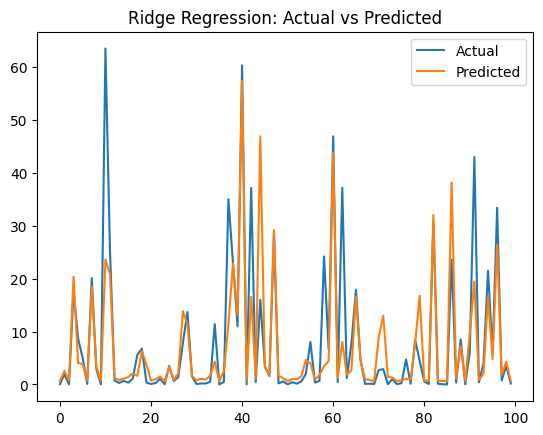

In [19]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(y_val[:100], label="Actual")
plt.plot(val_pred[:100], label="Predicted")
plt.title("Ridge Regression: Actual vs Predicted")
plt.legend()
plt.show()